In [10]:
import os
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from itertools import product

In [11]:
IMG_SIZE = (128, 128)
DATA_DIR = "data_chipolino"

def load_and_resize(path, size=IMG_SIZE):
    img = mpimg.imread(path)
    img = (img).astype(np.uint8)
    img = Image.fromarray(img).resize(size, Image.BILINEAR)
    return np.asarray(img, dtype=np.float32) / 255.0

images_onion = []
images_tomato = []

for i in range(1, 21):
    p = os.path.join(DATA_DIR, f"tomato{i}.jpg")
    images_tomato.append(load_and_resize(p))
    p = os.path.join(DATA_DIR, f"onion{i}.jpg")
    images_onion.append(load_and_resize(p))
train_lst = images_onion[:15] + images_tomato[:15]
test_lst = images_onion[15:] + images_tomato[15:]

X_train = np.stack(train_lst)
X_test = np.stack(test_lst) 
y_train = np.array([0]*15 + [1]*15)
y_test = np.array([0]*5 + [1]*5) 

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (30, 128, 128, 3)
X_test: (10, 128, 128, 3)
y_train: (30,)
y_test: (10,)


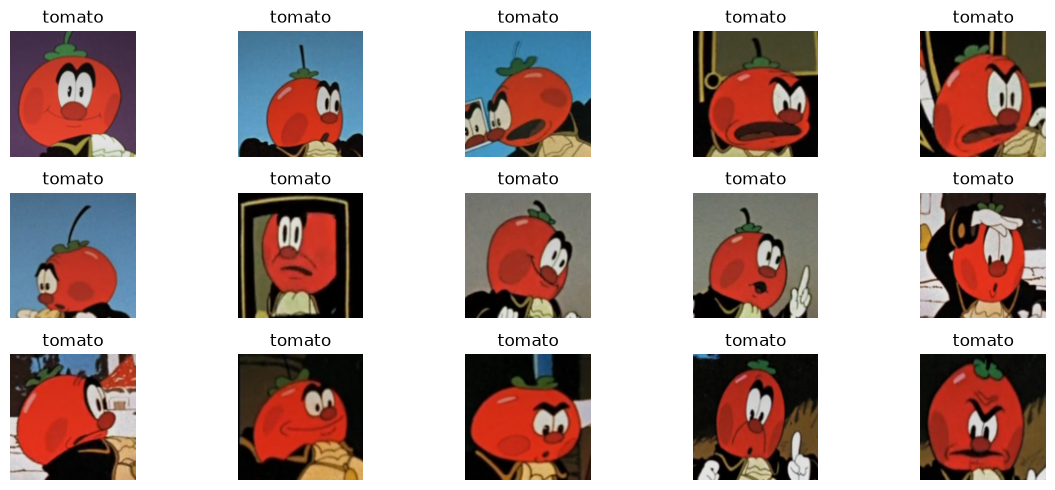

In [16]:
fig, axes = plt.subplots(3, 5, figsize=(12, 5))
for ax, img, lbl in zip(axes.ravel(), X_train[15:30], y_train[15:30]):
    ax.imshow(img)
    ax.set_title("onion" if lbl == 0 else "tomato")
    ax.axis("off")
plt.tight_layout()
plt.show()

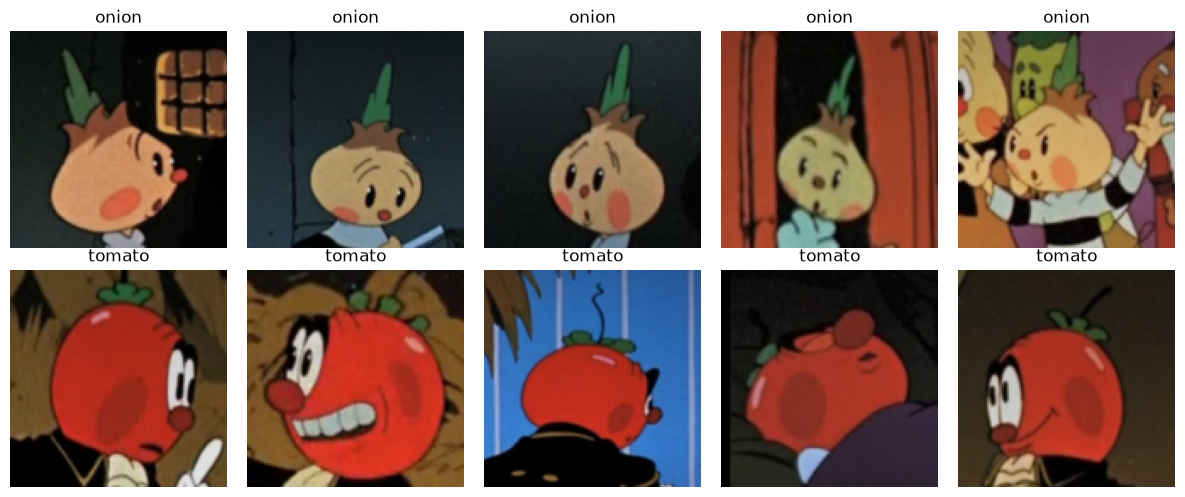

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, lbl in zip(axes.ravel(), X_test, y_test):
    ax.imshow(img)
    ax.set_title("onion" if lbl == 0 else "tomato")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [8]:
def to_tensor(x):
    x = np.transpose(x, (0, 3, 1, 2))       # (N,3,128,128)
    return torch.from_numpy(x).float()

In [9]:
X_train_t = to_tensor(X_train)
X_test_t  = to_tensor(X_test)
y_train_t = torch.from_numpy(y_train).long()   # long для CrossEntropyLoss
y_test_t  = torch.from_numpy(y_test).long()

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2, kernel_sizes = [3,3,3]):
        super().__init__()
        # вход: (3, 128, 128)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=kernel_sizes[0], padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=kernel_sizes[1], padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=kernel_sizes[2], padding=1)
        self.pool  = nn.MaxPool2d(2)

        self.gap   = nn.AdaptiveAvgPool2d(1)
        self.drop  = nn.Dropout(0.3)
        self.fc    = nn.Linear(64, num_classes)

    def forward(self, x):
        # 128 -> 64
        x = self.pool(F.relu(self.conv1(x)))
        # 64 -> 32
        x = self.pool(F.relu(self.conv2(x)))
        # 32 -> 16
        x = self.pool(F.relu(self.conv3(x)))

        x = self.gap(x)
        x = x.flatten(1)
        x = self.drop(x)
        return self.fc(x) 

In [ ]:
def train_model(model, train_loader, test_loader,
                epochs=30, lr=1e-3, weight_decay=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        # ---------- TRAIN ----------
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total   += yb.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # ---------- EVAL ----------
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb).argmax(dim=1)
                correct += (preds == yb).sum().item()
                total   += yb.size(0)
        test_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        # print(f"Epoch {epoch:3d}/{epochs} | "
        #       f"loss={train_loss:.4f} | "
        #       f"train_acc={train_acc:.3f} | "
        #       f"test_acc={test_acc:.3f}")

    return history

# --- запуск ---
model = SimpleCNN(num_classes=2,kernel_sizes = [3,3,3])
history = train_model(model, train_loader, test_loader,
                      epochs=100, lr=1e-3, weight_decay=1e-4)

In [ ]:
results = []

for kernel_sizes, lr, wd in product([(3,3,3), (5,3,3),(5,5,3),(5,5,5)], [1e-3, 5e-4, 1e-4], [1e-4,1e-3,1e-5]):
    torch.manual_seed(42)
    model = SimpleCNN(num_classes=2, kernel_sizes=kernel_sizes)
    history = train_model(model, train_loader, test_loader,
                          epochs=40, lr=lr, weight_decay=wd)
    acc = history["test_acc"][-1]
    results.append((kernel_sizes, lr, wd, acc, model,history))
    print(kernel_sizes, lr, wd, "->", round(acc, 3))

best = max(results, key=lambda r: r[-3])
print("Лучшее:", best[:-2])
best_model = best[-2]
hist_best_model = best[-1]

In [ ]:
import matplotlib.pyplot as plt
history = hist_best_model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history["train_loss"]); ax1.set_title("train loss"); ax1.set_xlabel("epoch")
ax2.plot(history["train_acc"], label="train")
ax2.plot(history["test_acc"],  label="test")
ax2.set_title("accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
plt.tight_layout(); plt.show()

In [ ]:
model.eval()

with torch.no_grad():
    probs = torch.softmax(best_model(X_test_t.to(device)), dim=1).cpu().numpy()
preds = probs.argmax(axis=1)

names = ["onion", "tomato"]

# сетка картинок
n = len(X_test)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = axes.ravel()

for i in range(n):
    axes[i].imshow(X_test[i])
    axes[i].set_title(f"true={names[y_test[i]]}\npred={names[preds[i]]}", fontsize=10)
    axes[i].axis("off")

# спрятать пустые ячейки, если n не делится на cols
for j in range(n, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model = results[6][-2]
model.eval()
with torch.no_grad():
    probs = torch.softmax(model(X_test_t.to(device)), dim=1).cpu().numpy()
preds = probs.argmax(axis=1)

names = ["onion", "tomato"]

# сетка картинок
n = len(X_test)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = axes.ravel()

for i in range(n):
    axes[i].imshow(X_test[i])
    axes[i].set_title(f"true={names[y_test[i]]}\npred={names[preds[i]]}", fontsize=10)
    axes[i].axis("off")

# спрятать пустые ячейки, если n не делится на cols
for j in range(n, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()